DO NOT RUN ALL

In [ ]:
!pip install -q gradio folium

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import gradio as gr
import folium
from IPython.display import display

print("All packages loaded.")
print("TensorFlow version:", tf.__version__)

All packages loaded.
TensorFlow version: 2.20.0


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/NCCU_BUILDINGS'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Drive mounted.")
if os.path.exists(DATASET_PATH):
    print("Found! Subfolders:", os.listdir(DATASET_PATH))
else:
    print("ERROR: Path not found. Check DATASET_PATH spelling.")

Drive mounted.
Found! Subfolders: ['Da Yong Building', 'Administration Building', 'College of Communication', 'Ji Tao Building', 'Main Library', 'unknown', 'College of Law', 'Art & Culture Center', 'Ji Ying Building', 'Student Club Center', 'College of Commerce', 'Dao Fan Building (College of Foreign Language)', 'Information Building', 'Lohas Plaza', 'Si Wei Hall', 'Yi Xian Building', 'Zi Chiang Dormitory 9', 'Zi Chiang Dormitory 7 & 8', 'Zi Chiang Dormitory 10', 'Bai Nian Building (College of Liberal Arts)', 'Syue Sih Building', 'Computer Center', 'General Building of Colleges', 'International Building', 'Zi Chiang Dormitory 5 & 6', 'THÔNG TIN TỪNG TÒA.gdoc']


In [ ]:
# =============================================================================
# BUILDING DATABASE — all 24 buildings + unknown
# =============================================================================
BUILDING_INFO = {
    "16": {
        "name": "Administration Building (A19)",
        "lat": 24.986397243857887, "lng": 121.575106644164,
        "facilities": [
            "Restaurant", "OIC office", "Libraries",
            "Accounting Office Secretariat", "First-bank counter",
            "Registration place", "Paying tuition fee"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "36": {
        "name": "International Building (A37)",
        "lat": 24.981224735011736, "lng": 121.57234936956658,
        "facilities": [
            "Available disabled restroom", "Elevator to dormitory",
            "ICI office", "College of Chinese"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Haohan Slope",
            "lat": 24.981346, "lng": 121.572134,
        }
    },
    "21": {
        "name": "Da Yong Building (A26)",
        "lat": 24.986867602331923, "lng": 121.57377441088424,
        "facilities": [
            "Wheelchair ramp", "Disabled accessible way",
            "Restroom for all genders"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "27": {
        "name": "General Building of Colleges (A28)",
        "lat": 24.986497998091508, "lng": 121.57346347754145,
        "facilities": [
            "Multiple college classrooms", "Cafeteria", "ATM",
            "Library", "Vending machines"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "06": {
        "name": "Main Library (A9)",
        "lat": 24.986141896939888, "lng": 121.57655173391917,
        "facilities": [
            "Reading rooms", "Study carrels",
            "Multimedia resource areas",
            "Computer labs with printers, scanners"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.57534,
        }
    },
    "26": {
        "name": "College of Commerce (A8)",
        "lat": 24.98681897898711, "lng": 121.57701909547322,
        "facilities": [
            "7-11 convenience store", "Library",
            "Computer Laboratories", "E.SUN Hall", "Open Dining hall"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.57534,
        }
    },
    "12": {
        "name": "Student Club Center (A12)",
        "lat": 24.987452778891225, "lng": 121.57542815606949,
        "facilities": ["Club Offices", "Meeting Rooms"],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "14": {
        "name": "Information Building (A15)",
        "lat": 24.981244185235738, "lng": 121.57275666261557,
        "facilities": ["Multiple college classrooms"],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "14b": {
        "name": "Computer Center (A16)",
        "lat": 24.987313112817183, "lng": 121.57491361711492,
        "facilities": [
            "PC classrooms", "Equipment loans", "Printing services",
            "Cloud computing resources", "ATM"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.57534,
        }
    },
    "11": {
        "name": "Si Wei Hall (A17)",
        "lat": 24.98642274250329, "lng": 121.57580339999527,
        "facilities": ["Multi-purpose auditorium", "Event space"],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "33": {
        "name": "Bai Nian Building (A33)",
        "lat": 24.981896951194354, "lng": 121.5736971134876,
        "facilities": ["Multiple college classrooms"],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Bai Nian Building",
            "lat": 24.982033698056355, "lng": 121.57380162797972,
        }
    },
    "37": {
        "name": "Art & Culture Center (A35)",
        "lat": 24.982046504315516, "lng": 121.57336419273878,
        "facilities": [
            "Auditorium", "Art gallery",
            "Audiovisual theater", "Practice rooms"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Art & Culture Center",
            "lat": 24.98208788135209, "lng": 121.57275071660179,
        }
    },
    "31": {
        "name": "College of Communication (A29)",
        "lat": 24.983057905143294, "lng": 121.57494038346692,
        "facilities": [
            "Communication Library", "Media labs",
            "Multiple college classrooms"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "04": {
        "name": "Syue Sih Building (A5)",
        "lat": 24.987305872441162, "lng": 121.57694478650748,
        "facilities": ["Multiple college classrooms"],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "LP": {
        "name": "Lohas Plaza",
        "lat": 24.987598, "lng": 121.574971,
        "facilities": [
            "Hair Salon", "Watches & Glasses", "Sports Goods shop",
            "Restaurants", "Muslim Prayer room", "IA meeting room"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "17": {
        "name": "Ji Ying Building (A22)",
        "lat": 24.9872983947391, "lng": 121.57438765767176,
        "facilities": ["Bookstore", "Restaurants"],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "34": {
        "name": "Ji Tao Building (A34)",
        "lat": 24.98138820125348, "lng": 121.57304395581977,
        "facilities": ["Multiple college classrooms"],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Bai Nian Building",
            "lat": 24.982033698056355, "lng": 121.57380162797972,
        }
    },
    "05": {
        "name": "Yi Xian Building (A7)",
        "lat": 24.986906071568487, "lng": 121.576870257397,
        "facilities": [
            "Multiple college classrooms",
            "Office of International Programs",
            "IMBA Office", "Student Support Services"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "32": {
        "name": "Dao Fan Building (A31)",
        "lat": 24.981285509469764, "lng": 121.57309272884261,
        "facilities": [
            "College of Foreign Languages & Literature Administrative Office",
            "DKLC Library", "Multiple college classrooms"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Bai Nian Building",
            "lat": 24.982033698056355, "lng": 121.57380162797972,
        }
    },
    "CL": {
        "name": "College of Law",
        "lat": 24.986197814090986, "lng": 121.57723769604483,
        "facilities": [
            "Multiple college classrooms", "Moot Court",
            "Seminars", "Lecture halls"
        ],
        "bus_stop": {
            "name": "Route 1, 2, 3 - Administration Building",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
    "68a": {
        "name": "Zi Chiang Dormitory No. 7 & 8",
        "lat": 24.97930309846358, "lng": 121.57019012538915,
        "facilities": ["Dormitory"],
        "bus_stop": {
            "name": "Route 2, 3 - Hillside Learning Lodge",
            "lat": 24.979568415560813, "lng": 121.57088577023391,
        }
    },
    "69": {
        "name": "Zi Chiang Dormitory No. 10",
        "lat": 24.98043381830459, "lng": 121.57228839222617,
        "facilities": ["Dormitory", "Restaurants", "Hi-life convenient store"],
        "bus_stop": {
            "name": "Route 2 - Zi Chiang 10th Dorm",
            "lat": 24.980025, "lng": 121.571742,
        }
    },
    "68b": {
        "name": "Zi Chiang Dormitory No. 5 & 6",
        "lat": 24.979111416331573, "lng": 121.57025214409346,
        "facilities": ["Dormitory"],
        "bus_stop": {
            "name": "Route 2, 3 - Hillside Learning Lodge",
            "lat": 24.979568415560813, "lng": 121.57088577023391,
        }
    },
    "71": {
        "name": "Zi Chiang Dormitory No. 9 (Hillside Learning Lodge)",
        "lat": 24.979991462944838, "lng": 121.57146149246408,
        "facilities": ["Dormitory", "Restaurants"],
        "bus_stop": {
            "name": "Route 2, 3 - Hillside Learning Lodge",
            "lat": 24.979568415560813, "lng": 121.57088577023391,
        }
    },
    "unknown": {
        "name": "Unknown Building",
        "lat": 24.9871, "lng": 121.5751,
        "facilities": [],
        "bus_stop": {
            "name": "N/A",
            "lat": 24.985956, "lng": 121.575346,
        }
    },
}

# =============================================================================
# FOLDER → CODE mapping
# Keys must match Google Drive folder names EXACTLY (case-sensitive)
# =============================================================================
FOLDER_TO_CODE = {
    "Administration Building":                          "16",
    "International Building":                           "36",
    "Da Yong Building":                                 "21",
    "General Building of Colleges":                     "27",
    "Main Library":                                     "06",
    "College of Commerce":                              "26",
    "Student Club Center":                              "12",
    "Information Building":                             "14",
    "Computer Center":                                  "14b",
    "Si Wei Hall":                                      "11",
    "Bai Nian Building (College of Liberal Arts)":      "33",
    "Art & Culture Center":                             "37",
    "College of Communication":                         "31",
    "Syue Sih Building":                                "04",
    "Lohas Plaza":                                      "LP",
    "Ji Ying Building":                                 "17",
    "Ji Tao Building":                                  "34",
    "Yi Xian Building":                                 "05",
    "Dao Fan Building (College of Foreign Language)":   "32",
    "College of Law":                                   "CL",
    "Zi Chiang Dormitory 7 & 8":                        "68a",
    "Zi Chiang Dormitory 10":                           "69",
    "Zi Chiang Dormitory 5 & 6":                        "68b",
    "Zi Chiang Dormitory 9":                            "71",
    "unknown":                                          "unknown",
}

# Reverse map: code -> folder name (used during prediction)
CODE_TO_FOLDER = {v: k for k, v in FOLDER_TO_CODE.items()}

In [ ]:
import os

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(f"{folder}: {len(files)} items")

        for f in files[:3]:
            print("   ->", f)

Da Yong Building: 27 items
   -> IMG_9995.jpg
   -> IMG_9993.jpg
   -> IMG_9998.jpg
Administration Building: 20 items
   -> IMG_0052.png
   -> IMG_0054.png
   -> IMG_0053.png
College of Communication: 26 items
   -> DJI_20260520112449_0767_D.JPG
   -> DJI_20260520112517_0768_D.JPG
   -> DJI_20260520112530_0769_D.JPG
Ji Tao Building: 54 items
   -> DJI_20260520105615_0624_D.JPG
   -> DJI_20260520105624_0625_D.JPG
   -> DJI_20260520105630_0626_D.JPG
Main Library: 46 items
   -> IMG_5479.jpg
   -> IMG_5480.jpg
   -> IMG_5481.jpg
unknown: 350 items
   -> unknown_11.jpg
   -> unknown_12.jpg
   -> unknown_13.jpg
College of Law: 65 items
   -> IMG_2992.jpg
   -> IMG_3001.jpg
   -> IMG_2997.jpg
Art & Culture Center: 53 items
   -> DJI_20260520104603_0570_D.JPG
   -> DJI_20260520104619_0571_D.JPG
   -> DJI_20260520104622_0572_D.JPG
Ji Ying Building: 11 items
   -> IMG_3036.jpg
   -> IMG_3039.jpg
   -> IMG_3034.jpg
Student Club Center: 50 items
   -> IMG_3048.jpg
   -> IMG_3046.jpg
   -> IMG_305

No need to run this cell

In [ ]:
import os
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed

def check_image(fpath):
    try:
        with Image.open(fpath) as img:
            img.verify()
        # verify() resets the file, must reopen to actually decode
        with Image.open(fpath) as img:
            img.convert("RGB")  # force full decode — catches corrupt JPEG data
        return None  # OK
    except Exception:
        return fpath  # broken

def remove_broken_images_fast(dataset_path, max_workers=32):
    all_files = []
    for root, dirs, files in os.walk(dataset_path):
        for fname in files:
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_files.append(os.path.join(root, fname))

    print(f"Checking {len(all_files)} images with {max_workers} threads...")

    broken = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(check_image, f): f for f in all_files}
        for i, future in enumerate(as_completed(futures)):
            result = future.result()
            if result:
                broken.append(result)
            if (i + 1) % 100 == 0:
                print(f"  Checked {i + 1}/{len(all_files)}...")

    for fpath in broken:
        print(f"  Removing broken file: {fpath}")
        os.remove(fpath)

    print(f"Done. Removed {len(broken)} broken image(s).")

remove_broken_images_fast(DATASET_PATH)

Checking 1539 images with 32 threads...
  Checked 100/1539...
  Checked 200/1539...
  Checked 300/1539...
  Checked 400/1539...
  Checked 500/1539...
  Checked 600/1539...
  Checked 700/1539...
  Checked 800/1539...
  Checked 900/1539...
  Checked 1000/1539...
  Checked 1100/1539...
  Checked 1200/1539...
  Checked 1300/1539...
  Checked 1400/1539...
  Checked 1500/1539...
Done. Removed 0 broken image(s).


In [ ]:
import tensorflow as tf
import random

AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_and_augment(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def load_no_augment(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

all_paths, all_labels = [], []
class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

for label_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_PATH, class_name)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(class_dir, fname))
            all_labels.append(label_idx)

total = len(all_paths)
print(f"Total images: {total}")

combined = list(zip(all_paths, all_labels))
random.shuffle(combined)
split = int(0.8 * total)
train_data = combined[:split]
val_data   = combined[split:]

train_paths, train_labels = zip(*train_data)
val_paths,   val_labels   = zip(*val_data)

train_ds = (
    tf.data.Dataset.from_tensor_slices((list(train_paths), list(train_labels)))
    .shuffle(len(train_paths), reshuffle_each_iteration=True)
    .map(load_and_augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((list(val_paths), list(val_labels)))
    .map(load_no_augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

RAW_CLASS_NAMES = class_names
print("Pipeline ready")

Classes: ['Administration Building', 'Art & Culture Center', 'Bai Nian Building (College of Liberal Arts)', 'College of Commerce', 'College of Communication', 'College of Law', 'Computer Center', 'Da Yong Building', 'Dao Fan Building (College of Foreign Language)', 'General Building of Colleges', 'Information Building', 'International Building', 'Ji Tao Building', 'Ji Ying Building', 'Lohas Plaza', 'Main Library', 'Si Wei Hall', 'Student Club Center', 'Syue Sih Building', 'Yi Xian Building', 'Zi Chiang Dormitory 10', 'Zi Chiang Dormitory 5 & 6', 'Zi Chiang Dormitory 7 & 8', 'Zi Chiang Dormitory 9', 'unknown']
Number of classes: 25
Total images: 1420
Pipeline ready


In [ ]:
from tensorflow.keras import layers, models

def one_hot(img, label):
    return img, tf.one_hot(label, NUM_CLASSES)

train_ds_oh = train_ds.map(one_hot, num_parallel_calls=AUTOTUNE)
val_ds_oh   = val_ds.map(one_hot,   num_parallel_calls=AUTOTUNE)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,177 (9.25 MB)

 Trainable params: 167,193 (653.10 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

!

In [ ]:
SKIP_TRAINING = True  # Change to False only when want to retrain

if not SKIP_TRAINING:
    history = model.fit(
        train_ds_oh,
        epochs=20,
        validation_data=val_ds_oh,
        callbacks=callbacks
    )
    model.save('/content/drive/MyDrive/nccu_campus_model.h5')
    print("Model saved.")
else:
    print("Skipping training - loading saved model instead.")
    model = tf.keras.models.load_model('/content/drive/MyDrive/nccu_campus_model.h5')

Skipping training - loading saved model instead.


Remember to skip training if already have file "nccu_campus_model.h5" in Drive

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 188s 5s/step - accuracy: 0.3565 - loss: 2.3883 - val_accuracy: 0.5704 - val_loss: 1.7135 - learning_rate: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.6136 - loss: 1.4662 - val_accuracy: 0.6831 - val_loss: 1.2315 - learning_rate: 0.0010
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 208s 4s/step - accuracy: 0.7289 - loss: 1.0306 - val_accuracy: 0.7500 - val_loss: 1.0160 - learning_rate: 0.0010
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.7782 - loss: 0.7961 - val_accuracy: 0.7676 - val_loss: 0.9308 - learning_rate: 0.0010
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 148s 4s/step - accuracy: 0.8389 - loss: 0.6195 - val_accuracy: 0.7817 - val_loss: 0.8054 - learning_rate: 0.0010
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.8803 - loss: 0.4762 - val_accuracy: 0.7923 - val_loss: 0.8007 - learning_rate: 0.0010
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.8900 - loss: 0.4268 - val_acc

Model saved to Drive.


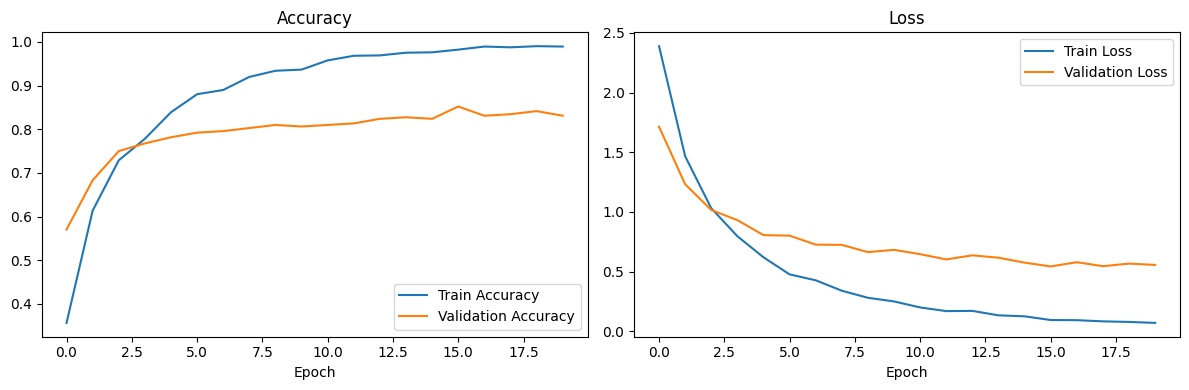

In [ ]:
import matplotlib.pyplot as plt

SKIP_TRAINING = False  # Set True to skip and load saved model

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

if not SKIP_TRAINING:
    history = model.fit(
        train_ds_oh,
        epochs=20,
        validation_data=val_ds_oh,
        callbacks=callbacks
    )
    model.save('/content/drive/MyDrive/nccu_campus_model.h5')
    print("Model saved to Drive.")

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    model = tf.keras.models.load_model('/content/drive/MyDrive/nccu_campus_model.h5')
    print("Model loaded from Drive.")

In [ ]:
def predict_building(image):
    if image is None:
        return "No image provided.", None

    img = tf.image.resize(image, IMG_SIZE) / 255.0
    img = tf.expand_dims(img, 0)

    predictions = model.predict(img, verbose=0)
    confidence = float(np.max(predictions))
    raw_folder = RAW_CLASS_NAMES[np.argmax(predictions)]

    # Debug: show confidence for all buildings
    print("All predictions:")
    for i in range(NUM_CLASSES):
        folder = RAW_CLASS_NAMES[i]
        code = FOLDER_TO_CODE.get(folder, "unknown")
        print(f"  {BUILDING_INFO.get(code, {}).get('name', folder)}: {float(predictions[0][i]):.1%}")

    code = FOLDER_TO_CODE.get(raw_folder, None)

    if confidence < 0.5 or code is None:
        return (
            f"Could not identify the building with sufficient confidence ({confidence:.1%}).\n"
            "Try taking the photo from a clearer angle or closer distance."
        ), None

    return code, confidence


def get_building_card(raw_input):
    code = str(raw_input).strip()

    if code not in BUILDING_INFO:
        available = ", ".join(sorted(BUILDING_INFO.keys()))
        return (
            f"<div style='padding:16px;color:#c0392b;font-family:Arial'>"
            f"Building code <b>{code}</b> not found.<br>"
            f"Available codes: {available}"
            f"</div>"
        )

    info = BUILDING_INFO[code]
    facilities_items = "".join([
        f"<li style='margin-bottom:6px;color:#2c3e50;font-size:14px'>• {f}</li>"
        for f in info['facilities']
    ])

    return (
        f"<div style='font-family:Arial;padding:18px;background:#ffffff;"
        f"border:1px solid #ccc;border-radius:10px;box-shadow:0 2px 6px rgba(0,0,0,0.08)'>"
        f"<h2 style='color:#2c3e50;margin-top:0;margin-bottom:12px'>{info['name']}</h2>"
        f"<div style='background:#f0f4f8;padding:12px;border-radius:8px'>"
        f"<h3 style='color:#34495e;font-size:14px;margin:0 0 8px 0;text-transform:uppercase;"
        f"letter-spacing:0.5px'>Facilities</h3>"
        f"<ul style='padding-left:0;margin:0;list-style:none;color:#2c3e50'>{facilities_items}</ul>"
        f"</div>"
        f"<p style='color:#aaa;font-size:11px;margin-top:12px;margin-bottom:0'>"
        f"Coordinates: {info['lat']}, {info['lng']}</p>"
        f"</div>"
    )


def get_map_html(raw_input):
    code = str(raw_input).strip()

    if code not in BUILDING_INFO:
        return "<p style='font-family:Arial;color:#c0392b'>Building not found.</p>"

    info = BUILDING_INFO[code]
    m = folium.Map(location=[info['lat'], info['lng']], zoom_start=18)

    folium.Marker(
        location=[info['lat'], info['lng']],
        popup=folium.Popup(f"<b>{info['name']}</b>", max_width=200),
        tooltip=f"{info['name']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)

    return m._repr_html_()


print("Helper functions ready.")

Helper functions ready.


In [ ]:
from huggingface_hub import login
from google.colab import userdata

login(userdata.get('HUGGING_FACE'))

In [ ]:
with gr.Blocks(title="NCCU Compass") as app:

    gr.Markdown("## NCCU Compass")
    gr.Markdown(
        "Use the **Image Recognition** tab to identify a building from a photo, "
        "or the **Search by Code** tab to look up any building directly."
    )

    with gr.Tabs():

        with gr.TabItem("Image Recognition"):
            gr.Markdown(
                "Upload a photo of a building on campus or take one with your camera. "
                "The model will identify the building and show its information."
            )
            with gr.Row():
                with gr.Column(scale=1):
                    image_input = gr.Image(
                        label="Upload photo or use camera",
                        sources=["upload", "webcam"],
                        type="numpy"
                    )
                    identify_button = gr.Button("Identify Building", variant="primary")
                with gr.Column(scale=2):
                    prediction_output = gr.Textbox(label="Prediction Result", lines=2, interactive=False)
                    info_output_tab1 = gr.HTML(label="Building Information")
                    map_output_tab1 = gr.HTML(label="Map")

            def run_image_recognition(image):
                code, confidence = predict_building(image)
                if confidence is None:
                    return code, "<p style='color:#c0392b;font-family:Arial'>Could not identify building.</p>", ""
                result_text = f"Identified: {BUILDING_INFO[code]['name']} (Code: {code}) | Confidence: {confidence:.1%}"
                card = get_building_card(code)
                map_html = get_map_html(code)
                return result_text, card, map_html

            identify_button.click(
                fn=run_image_recognition,
                inputs=image_input,
                outputs=[prediction_output, info_output_tab1, map_output_tab1]
            )

        with gr.TabItem("Search by Code"):
            gr.Markdown(
                "Type a building code (16, 21, 27, or 36) to view its facilities, "
                "nearby bus stops, and location on the map."
            )
            with gr.Row():
                search_box = gr.Textbox(
                    label="Building Code",
                    placeholder="Enter code: 16, 21, 27, 36 ...",
                    scale=4
                )
                search_button = gr.Button("Search", variant="primary", scale=1)

            with gr.Row():
                with gr.Column():
                    photo_gallery = gr.Gallery(
                        label="Building Photos",
                        columns=1,
                        rows=1,
                        height=480,
                        object_fit="cover",
                        show_label=True
                    )
                    info_output_tab2 = gr.HTML(label="Building Information")
                with gr.Column():
                    map_output_tab2 = gr.HTML(label="Map")

            def run_search(code):
                photos = get_photos(code)
                card = get_building_card(code)
                map_html = get_map_html(code)
                return photos, card, map_html

            search_button.click(
                fn=run_search,
                inputs=search_box,
                outputs=[photo_gallery, info_output_tab2, map_output_tab2]
            )
            search_box.submit(
                fn=run_search,
                inputs=search_box,
                outputs=[photo_gallery, info_output_tab2, map_output_tab2]
            )

    gr.Markdown("---\nNCCU Compass - Campus Building Recognition App")

app.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5ad220c8da3e764839.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Only run this when training is complete (final)

In [ ]:
# Right after model.fit() finishes, save and push in one go
model.save("nccu_campus_model.h5")

from huggingface_hub import HfApi
from google.colab import userdata

api = HfApi()
api.upload_file(
    path_or_fileobj="nccu_campus_model.h5",
    path_in_repo="nccu_campus_model.h5",
    repo_id="bonki67/nccu-compass",
    repo_type="space",
    token=userdata.get('HUGGING_FACE')
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  nccu_campus_model.h5        :  59%|#####8    | 6.70MB / 11.4MB            

CommitInfo(commit_url='https://huggingface.co/spaces/bonki67/nccu-compass/commit/29cd093949c77d400486ab1fd97ab3d6c655d4b8', commit_message='Upload nccu_campus_model.h5 with huggingface_hub', commit_description='', oid='29cd093949c77d400486ab1fd97ab3d6c655d4b8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/bonki67/nccu-compass', endpoint='https://huggingface.co', repo_type='space', repo_id='bonki67/nccu-compass'), pr_revision=None, pr_num=None)